# Speech Commands EDA and Data Processing Notebook

This notebook focuses on the **data analysis** and **data processing** stages of the project:

1. Inspect dataset availability and structure
2. Analyze class and split distributions
3. Check data quality (duration, sample rate)
4. Validate split integrity (speaker leakage checks)
5. Preview preprocessing outputs (waveform and Mel-spectrogram)

Use this notebook as evidence for the final report's data section.

In [1]:
from pathlib import Path
import json
import csv
import wave
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Notebook display defaults
plt.style.use("ggplot")
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 140)

# Project paths
NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent
DATA_DIR = PROJECT_ROOT / "data"
RAW_DIR = DATA_DIR / "raw"
PROCESSED_DIR = DATA_DIR / "processed"

print(f"Project root: {PROJECT_ROOT}")
print(f"Raw data dir exists: {RAW_DIR.exists()}")
print(f"Processed dir exists: {PROCESSED_DIR.exists()}")

Project root: d:\RNYUMUL\Speech-Command-Recognition
Raw data dir exists: True
Processed dir exists: True


## 1) Dataset Inventory

This section checks what is currently available in `data/raw` and `data/processed`.

If files are missing, run:

```bash
python data/get_data.py
```

In [2]:
def list_top_level_audio_labels(raw_dir: Path, limit: int = 15):
    if not raw_dir.exists():
        return []
    return sorted([p.name for p in raw_dir.iterdir() if p.is_dir()])[:limit]

print("Sample label folders:", list_top_level_audio_labels(RAW_DIR))

manifest_paths = {
    "train": PROCESSED_DIR / "train_manifest.csv",
    "val": PROCESSED_DIR / "val_manifest.csv",
    "test": PROCESSED_DIR / "test_manifest.csv",
}

for split_name, path in manifest_paths.items():
    print(f"{split_name}: {path.exists()} -> {path}")

metadata_path = PROCESSED_DIR / "metadata.json"
if metadata_path.exists():
    metadata = json.loads(metadata_path.read_text(encoding="utf-8"))
    print("\nMetadata labels:", metadata.get("labels", []))
    print("Examples per split:", metadata.get("examples_per_split", {}))
else:
    metadata = {}
    print("\nNo metadata.json yet. Generate it via data/get_data.py")

Sample label folders: ['_background_noise_', 'backward', 'bed', 'bird', 'cat', 'dog', 'down', 'eight', 'five', 'follow', 'forward', 'four', 'go', 'happy', 'house']
train: True -> d:\RNYUMUL\Speech-Command-Recognition\data\processed\train_manifest.csv
val: True -> d:\RNYUMUL\Speech-Command-Recognition\data\processed\val_manifest.csv
test: True -> d:\RNYUMUL\Speech-Command-Recognition\data\processed\test_manifest.csv

Metadata labels: ['next', 'pause', 'play', 'previous', 'stop', 'unknown']
Examples per split: {'train': 23262, 'test': 3034, 'val': 2715}


In [3]:
def load_manifest(path: Path) -> pd.DataFrame:
    if not path.exists():
        return pd.DataFrame()
    return pd.read_csv(path)

df_train = load_manifest(manifest_paths["train"])
df_val = load_manifest(manifest_paths["val"])
df_test = load_manifest(manifest_paths["test"])

print("Train shape:", df_train.shape)
print("Val shape:", df_val.shape)
print("Test shape:", df_test.shape)

if not df_train.empty:
    display(df_train.head(3))

Train shape: (23262, 10)
Val shape: (2715, 10)
Test shape: (3034, 10)


,path,raw_label,label,split,speaker_id,utterance_id,is_unknown,is_silence,segment_start,segment_duration
0,right/00b01445_nohash_0.wav,right,next,train,00b01445,0,0,0,0.0,1.0
1,right/012187a4_nohash_0.wav,right,next,train,012187a4,0,0,0,0.0,1.0
2,right/012187a4_nohash_1.wav,right,next,train,012187a4,1,0,0,0.0,1.0


## 2) Class and Split Distribution Analysis

This section verifies class balance and checks whether `unknown` and `silence` are represented properly.

,label,count,split
13,unknown,1011,test
14,previous,412,test
15,stop,411,test
16,pause,402,test
17,play,402,test
18,next,396,test
0,unknown,7621,train
1,stop,3111,train
2,play,3106,train
3,previous,3037,train


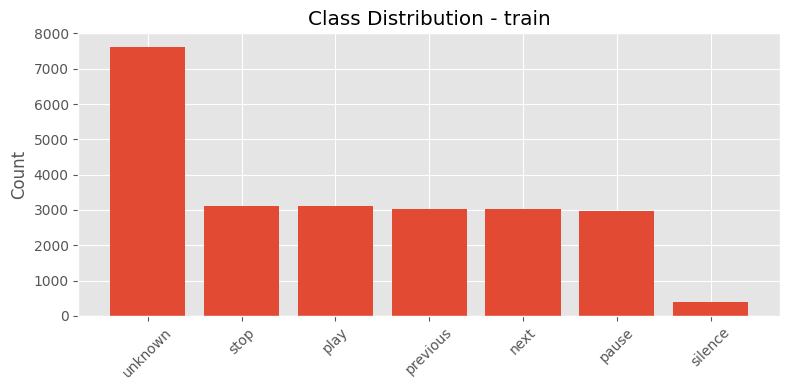

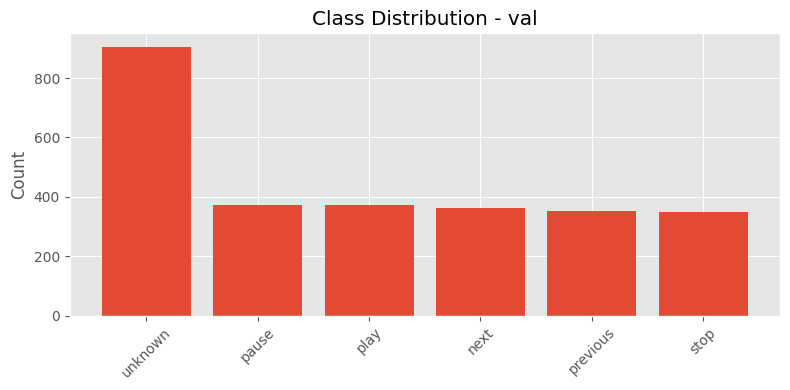

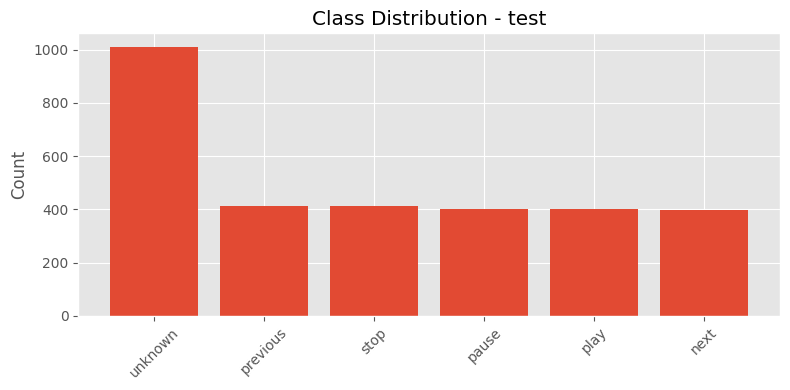

In [4]:
def class_distribution(df: pd.DataFrame, split_name: str) -> pd.DataFrame:
    if df.empty or "label" not in df.columns:
        return pd.DataFrame(columns=["label", "count", "split"])
    out = (
        df["label"]
        .value_counts()
        .rename_axis("label")
        .reset_index(name="count")
    )
    out["split"] = split_name
    return out

class_df = pd.concat(
    [
        class_distribution(df_train, "train"),
        class_distribution(df_val, "val"),
        class_distribution(df_test, "test"),
    ],
    ignore_index=True,
)

if class_df.empty:
    print("No manifest data loaded yet.")
else:
    display(class_df.sort_values(["split", "count"], ascending=[True, False]).head(20))

    for split_name in ["train", "val", "test"]:
        temp = class_df[class_df["split"] == split_name].sort_values("count", ascending=False)
        if temp.empty:
            continue
        plt.figure(figsize=(8, 4))
        plt.bar(temp["label"], temp["count"])
        plt.title(f"Class Distribution - {split_name}")
        plt.xticks(rotation=45)
        plt.ylabel("Count")
        plt.tight_layout()
        plt.show()

## 3) Data Quality Checks (Duration, Sample Rate, and Leakage)

These checks help verify preprocessing assumptions:
- WAV files are close to expected duration
- Sample rates are consistent
- Speaker IDs do not leak across splits

,label,sample_rate,duration,is_silence,is_unknown
count,300,300.0,300.000000,300.000000,300.000000
unique,7,NaN,NaN,NaN,NaN
top,unknown,NaN,NaN,NaN,NaN
freq,86,NaN,NaN,NaN,NaN
mean,NaN,16000.0,2.315316,0.016667,0.286667
std,NaN,0.0,10.536421,0.128233,0.452960
min,NaN,16000.0,0.480000,0.000000,0.000000
25%,NaN,16000.0,1.000000,0.000000,0.000000
50%,NaN,16000.0,1.000000,0.000000,0.000000
75%,NaN,16000.0,1.000000,0.000000,1.000000


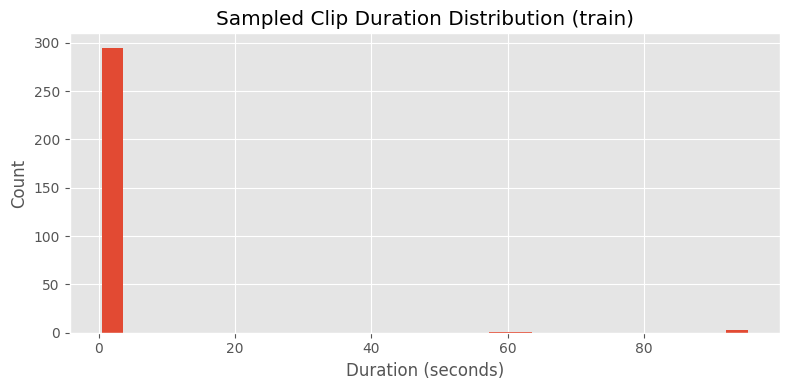

Sample rate counts:
sample_rate
16000    300
Name: count, dtype: int64


In [5]:
def wave_info(path: Path) -> dict:
    with wave.open(str(path), "rb") as wav_file:
        frames = wav_file.getnframes()
        rate = wav_file.getframerate()
        duration = frames / float(rate)
    return {"sample_rate": rate, "frames": frames, "duration": duration}


def sample_wave_stats(df: pd.DataFrame, n: int = 300) -> pd.DataFrame:
    if df.empty:
        return pd.DataFrame()

    sample_df = df.sample(min(n, len(df)), random_state=42)
    rows = []
    for _, row in sample_df.iterrows():
        file_path = RAW_DIR / row["path"]
        if not file_path.exists():
            continue
        info = wave_info(file_path)
        rows.append(
            {
                "label": row["label"],
                "sample_rate": info["sample_rate"],
                "duration": info["duration"],
                "is_silence": row.get("is_silence", 0),
                "is_unknown": row.get("is_unknown", 0),
            }
        )
    return pd.DataFrame(rows)

stats_df = sample_wave_stats(df_train, n=300)
if stats_df.empty:
    print("No waveform stats available yet.")
else:
    display(stats_df.describe(include="all"))

    plt.figure(figsize=(8, 4))
    plt.hist(stats_df["duration"], bins=30)
    plt.title("Sampled Clip Duration Distribution (train)")
    plt.xlabel("Duration (seconds)")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

    sr_counts = stats_df["sample_rate"].value_counts().sort_index()
    print("Sample rate counts:")
    print(sr_counts)

In [6]:
def check_speaker_leakage(df_a: pd.DataFrame, df_b: pd.DataFrame, name_a: str, name_b: str):
    if df_a.empty or df_b.empty or "speaker_id" not in df_a.columns or "speaker_id" not in df_b.columns:
        print(f"Cannot compute leakage for {name_a} vs {name_b}")
        return

    speakers_a = set(df_a["speaker_id"].dropna().astype(str))
    speakers_b = set(df_b["speaker_id"].dropna().astype(str))
    overlap = speakers_a.intersection(speakers_b)

    print(f"{name_a} speakers: {len(speakers_a)}")
    print(f"{name_b} speakers: {len(speakers_b)}")
    print(f"Overlap count: {len(overlap)}")
    if overlap:
        print("Sample overlapping speakers:", sorted(list(overlap))[:10])

check_speaker_leakage(df_train, df_val, "train", "val")
check_speaker_leakage(df_train, df_test, "train", "test")
check_speaker_leakage(df_val, df_test, "val", "test")

train speakers: 1979
val speakers: 243
Overlap count: 0
train speakers: 1979
test speakers: 240
Overlap count: 0
val speakers: 243
test speakers: 240
Overlap count: 0


## 4) Preprocessing Preview (Waveform and Mel-Spectrogram)

This section previews what the model sees after feature extraction.

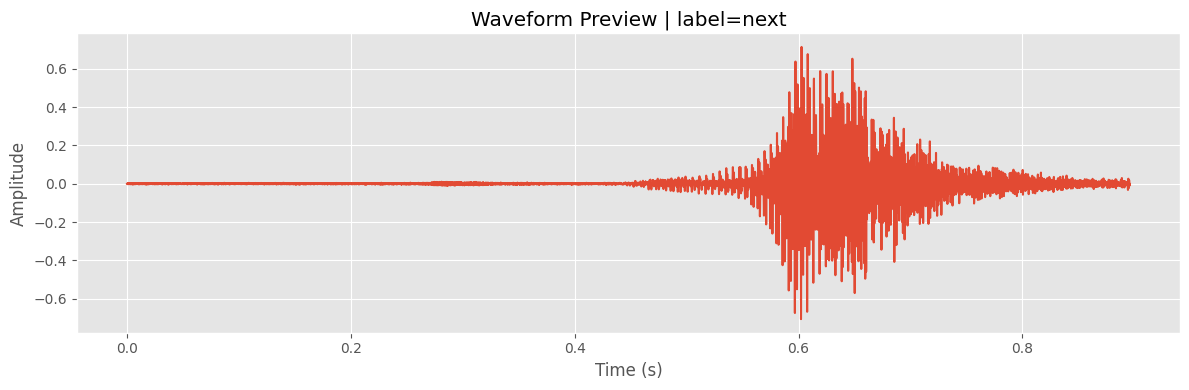

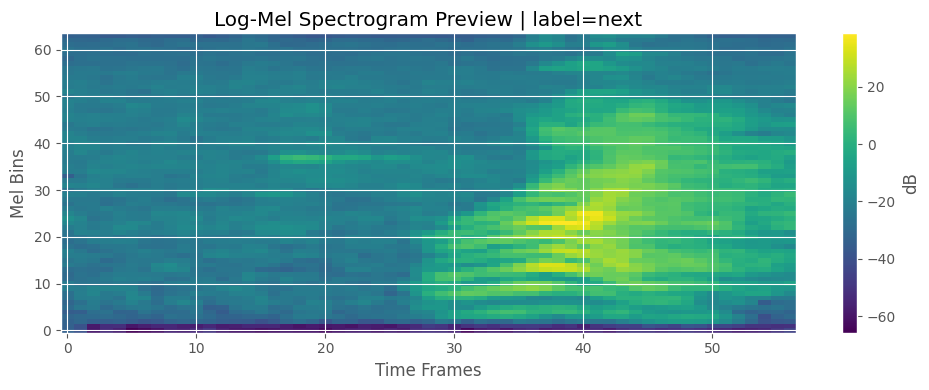

In [7]:
# Optional dependency-based preview cell
# This cell will gracefully skip if torch/torchaudio are not installed.

import importlib

has_torch = importlib.util.find_spec("torch") is not None
has_torchaudio = importlib.util.find_spec("torchaudio") is not None

if not has_torch or not has_torchaudio:
    print("Install torch + torchaudio to run spectrogram preview.")
else:
    import torch
    import torchaudio
    from torchaudio import transforms as T

    # Pick one non-silence example from train manifest for visualization.
    if df_train.empty:
        print("No train manifest available yet.")
    else:
        preview_row = df_train[df_train["is_silence"] == 0].head(1)
        if preview_row.empty:
            preview_row = df_train.head(1)

        row = preview_row.iloc[0]
        wav_path = RAW_DIR / row["path"]
        waveform, sr = torchaudio.load(str(wav_path))

        # Force mono and 16kHz to match pipeline assumptions.
        if waveform.size(0) > 1:
            waveform = waveform.mean(dim=0, keepdim=True)
        if sr != 16000:
            waveform = torchaudio.functional.resample(waveform, sr, 16000)
            sr = 16000

        mel_transform = T.MelSpectrogram(
            sample_rate=sr,
            n_fft=1024,
            hop_length=256,
            win_length=1024,
            n_mels=64,
            f_min=20.0,
            f_max=7600.0,
            power=2.0,
        )
        db_transform = T.AmplitudeToDB(stype="power")
        mel_db = db_transform(mel_transform(waveform)).squeeze(0).numpy()

        # Plot waveform and corresponding spectrogram.
        time_axis = np.arange(waveform.shape[-1]) / sr
        plt.figure(figsize=(12, 4))
        plt.plot(time_axis, waveform.squeeze(0).numpy())
        plt.title(f"Waveform Preview | label={row['label']}")
        plt.xlabel("Time (s)")
        plt.ylabel("Amplitude")
        plt.tight_layout()
        plt.show()

        plt.figure(figsize=(10, 4))
        plt.imshow(mel_db, origin="lower", aspect="auto")
        plt.title(f"Log-Mel Spectrogram Preview | label={row['label']}")
        plt.xlabel("Time Frames")
        plt.ylabel("Mel Bins")
        plt.colorbar(label="dB")
        plt.tight_layout()
        plt.show()

## 5) Processing Checklist Summary

Use this quick checklist before training:

- [ ] `data/get_data.py` executed successfully
- [ ] `train/val/test` manifests exist in `data/processed`
- [ ] Class distribution checked for imbalance
- [ ] Duration and sample rate assumptions validated
- [ ] Speaker leakage reviewed and documented
- [ ] Waveform + Mel-spectrogram preview generated

Once all checks pass, proceed with:

```bash
python src/train.py
```